In [7]:
import monte_carlo
import torch
import math
import matplotlib.pyplot as plt

In [2]:
def f(x):
    return x**2

mc_int = monte_carlo.MonteCarloIntegration(f)
inte, conf_int = mc_int.compute_integral(0, 1, n=1000000)

integral: 0.3335, Confidence Interval: (0.3329, 0.3341)


In [3]:
def f(x):
    return x**2

mc_int = monte_carlo.MonteCarloIntegration(f)
inte, conf_int = mc_int.compute_integral(-1, 1, n=1000000)

integral: 0.6666, Confidence Interval: (0.6654, 0.6677)


In [4]:
def f(x):
    return x**2-1  

mc_int = monte_carlo.MonteCarloIntegration(f)
inte, conf_int = mc_int.compute_integral(-1, 1, n=1000000)

integral: -1.3341, Confidence Interval: (-1.3353, -1.3330)


In [5]:
device =  torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [17]:
class EmpiricalCDF:
    def __init__(self, data):
 
        self.data = torch.sort(data).values.to(device)
        self.n = len(data)
        
    def compute(self, x, alpha=0.05, print_=True):

        x = x.to(device)
   
        count = torch.searchsorted(self.data, x, right=True)
        Fnx = count.float() / self.n
        
        ep = math.sqrt(math.log(2/alpha) / (2 * self.n))
        low = torch.clamp(Fnx - ep, 0., 1.)
        up = torch.clamp(Fnx + ep, 0., 1.)
        
        if print_ and Fnx.numel() == 1:
            print(f"ECDF: {Fnx.item():.4f}, Band: ({low.item():.4f}, {up.item():.4f})")
        return Fnx, (low, up)

    def plot(self, x_min, x_max, alpha=0.05, n_points=1000):

     
        points = torch.linspace(x_min, x_max, n_points, device=device)
        
        Fnx, (low, up) = self.compute(points, alpha=alpha, print_=False)
        
        plt.figure(figsize=(10, 6))
        plt.fill_between(points.cpu(), low.cpu(), up.cpu(), color='red', alpha=0.2, label='Banda de Confianza')
        plt.step(points.cpu(), Fnx.cpu(), where='post', label='ECDF', color='blue')
        
        plt.title(f"Empirical CDF con Banda de Confianza (α={alpha})")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

In [161]:
norm = torch.distributions.Normal(0,1)
n_sample = 10000
data = norm.sample((n_sample,))
norm_ecdf = EmpiricalCDF(data)
x = torch.Tensor([0.0])
integral, conf_int = norm_ecdf.compute(x)

ECDF: 0.4955, Band: (0.4819, 0.5091)


In [21]:
x = torch.Tensor([0.0, -1.0, 1.0])
integral, conf_int = norm_ecdf.compute(x)
integral

tensor([0.5050, 0.1571, 0.8440], device='cuda:0')

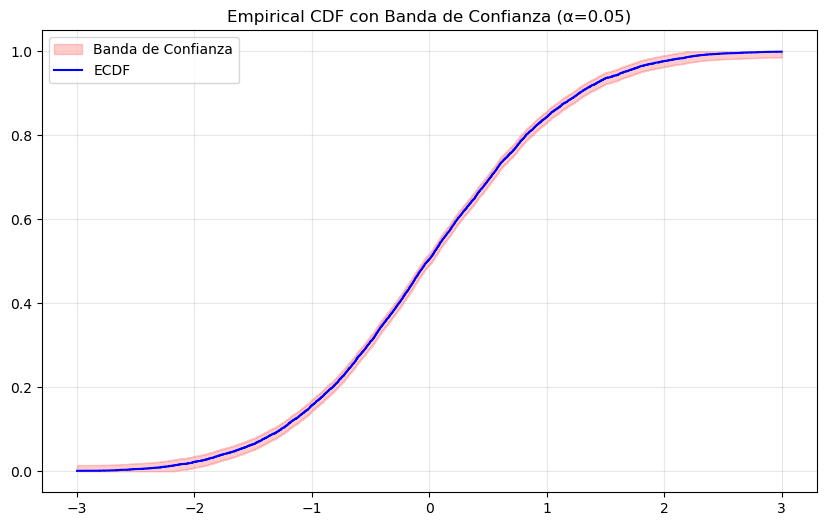

In [23]:
norm_ecdf.plot(-3.,3.,n_points=100000)

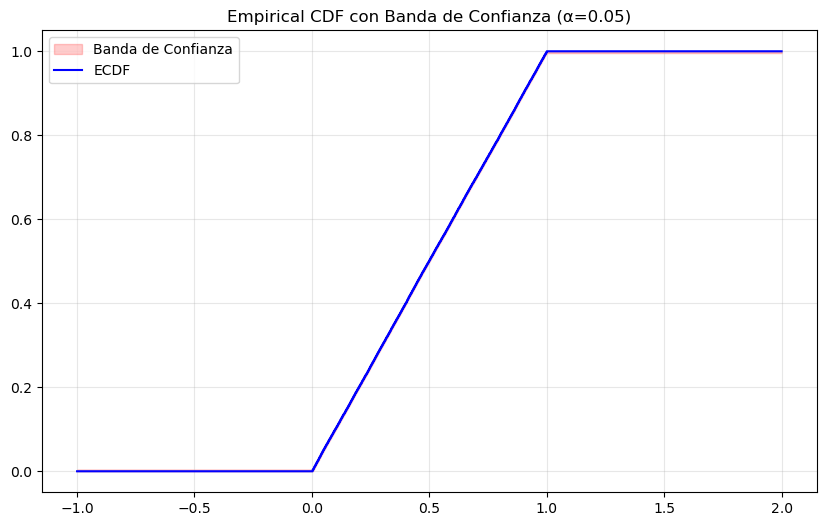

In [28]:
unif = torch.distributions.Uniform(0,1)
n_sample = 100000
data = unif.sample((n_sample,))
unif_ecdf = EmpiricalCDF(data)
unif_ecdf.plot(-1.0, 2.0, n_points=1000)

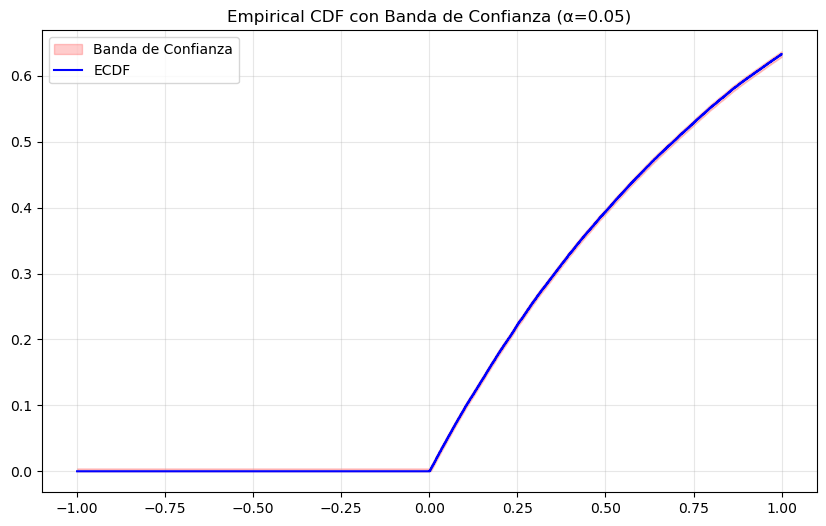

In [37]:
exp = torch.distributions.Exponential(1.0)
n_sample = 100000
data = exp.sample((n_sample,))
exp_ecdf = EmpiricalCDF(data)
exp_ecdf.plot(-1.0, 1.0, n_points=1000)

In [157]:
class EmpiricalPDF:

    def __init__(self, distribution):

        self.distribution = distribution
        
    def compute(self, x, n_sim=1000, n_groups=100, h = None):

        if h == None:

            h = n_groups**(-1/3)

        x = x.to(device)

        sample_ = self.distribution.sample((n_sim, n_groups)).to(device)
        sample_ = sample_.unsqueeze(-1)

        mask = (sample_> x) & (sample_ <= x+h)

        fx = mask.sum(dim=(0,1))/(n_sim*n_groups*h)

        return fx
    def plot(self, x_min, x_max, n_points=200, n_sim=1000, n_groups=100, h=None):
        

        x = torch.linspace(x_min, x_max, n_points).to(device)
    
        # estimador empírico
        fx_est = self.compute(x, n_sim=n_sim, n_groups=n_groups, h=h)
    
        # densidad real
        fx_true = torch.exp(self.distribution.log_prob(x))
    
        # mover a CPU para graficar
        x = x.cpu()
        fx_est = fx_est.cpu()
        fx_true = fx_true.cpu()
    
        plt.figure(figsize=(10,6))
    
        plt.plot(x, fx_true, label="True density", linewidth=2,color='red')
        plt.plot(x, fx_est, '--', label="Empirical PDF",color = 'blue')
    
        plt.xlabel("x")
        plt.ylabel("f(x)")
        plt.title("Empirical PDF vs True PDF")
    
        plt.legend()
        plt.grid(alpha=0.3)
    
        plt.show()

        
        
        
        

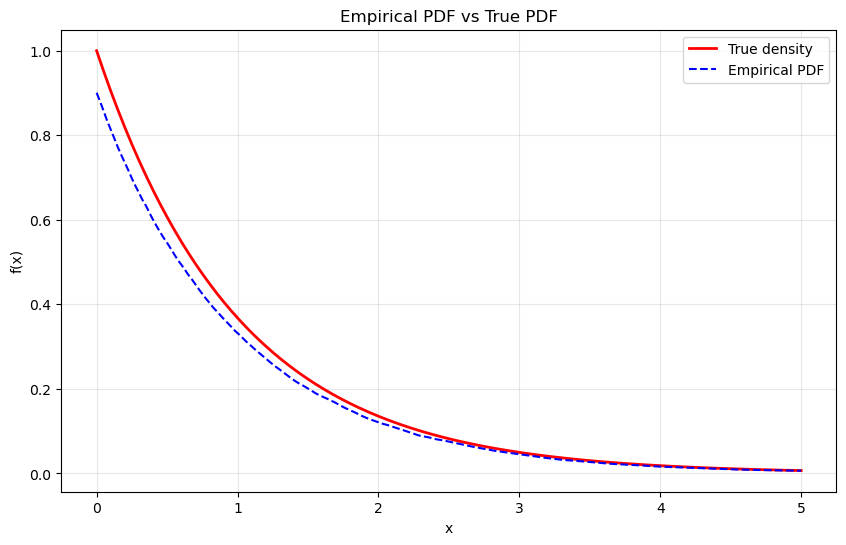

In [177]:
exp_pdf = EmpiricalPDF(exp)
exp_pdf.plot(0.0,5.0,n_sim=10000,n_groups=100)

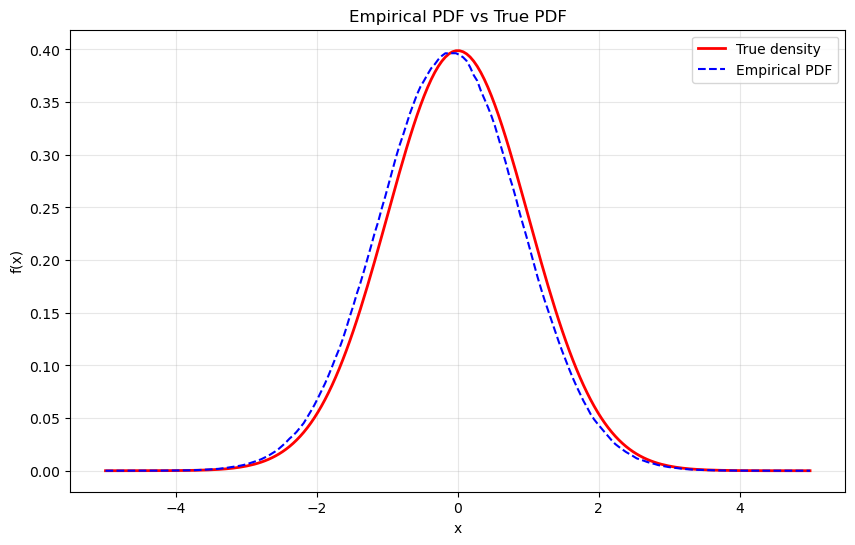

In [178]:
norm_pdf = EmpiricalPDF(norm)
norm_pdf.plot(-5.0,5.0,n_sim=10000,n_groups=100)

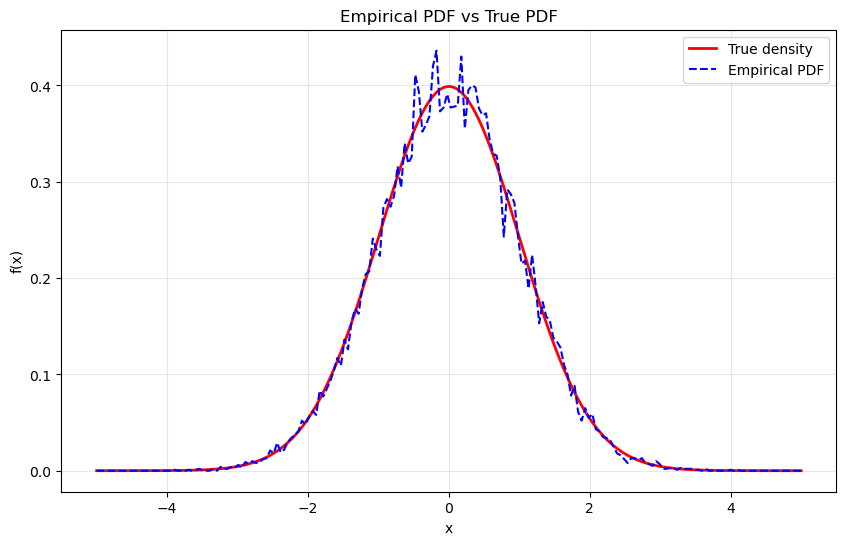

In [179]:
norm_pdf.plot(-5.0,5.0,n_sim=10000,n_groups=100,h=0.001)

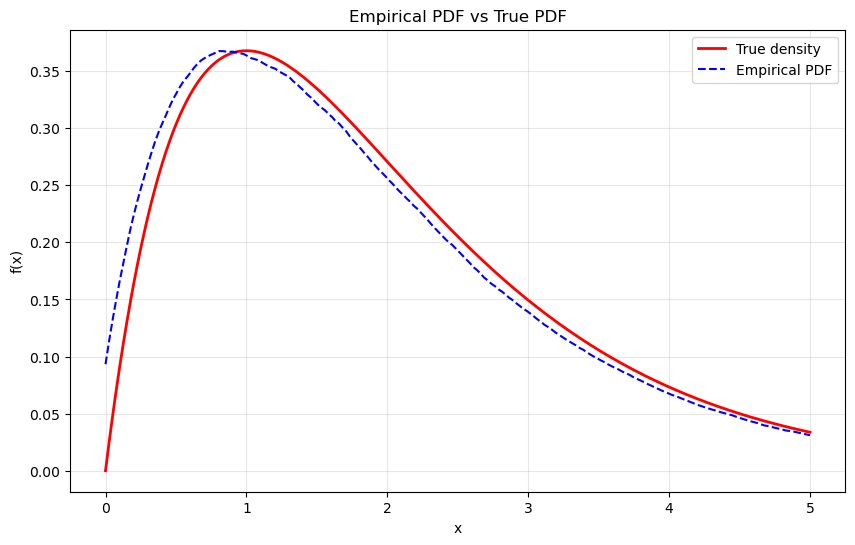

In [184]:
gam = torch.distributions.Gamma(2.0,1.0)
gam_pdf = EmpiricalPDF(gam)
gam_pdf.plot(0.0,5.0,n_sim=20000,n_groups=100)

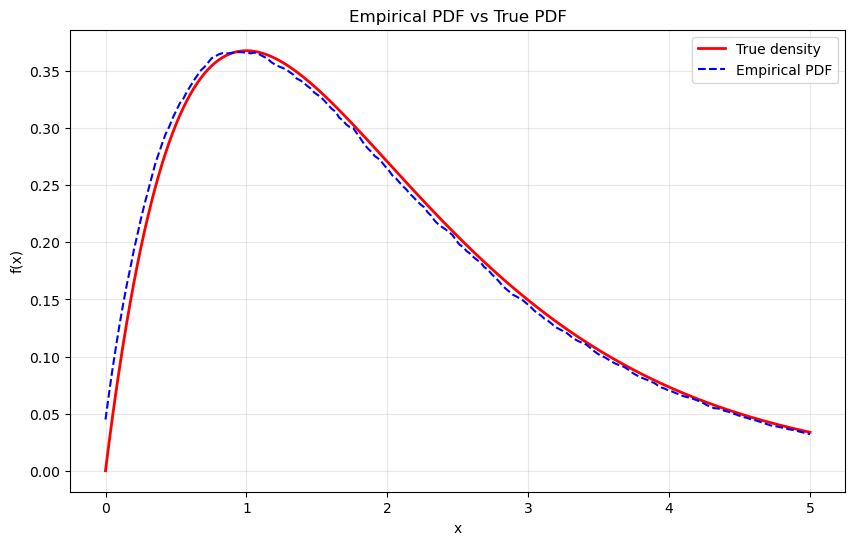

In [192]:
gam = torch.distributions.Gamma(2.0,1.0)
gam_pdf = EmpiricalPDF(gam)
gam_pdf.plot(0.0,5.0,n_sim=20000,n_groups=100,h=0.095)

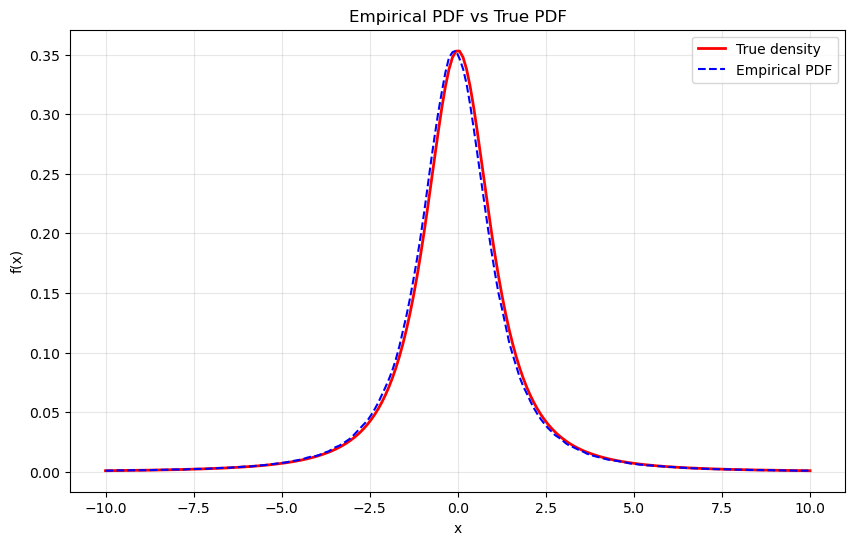

In [197]:
t = torch.distributions.StudentT(2)
t_pdf = EmpiricalPDF(t)
t_pdf.plot(-10, 10, n_sim=10000, n_groups=200)

In [239]:
class ParametricVaRCVaR:

    

    def __init__(self, distribution):

        self.distribution = distribution
        self.Z = torch.distributions.Normal(0, 1)

    def compute_VaR(self, n=1000, alpha=0.05, beta=0.05):
        
        sample_ = self.distribution.sample((n,)).to(device)
        VaR_hat = torch.quantile(sample_, alpha)

        beta2 = torch.Tensor([1-beta/2]).to(device)
        z_beta2 = self.Z.icdf(beta2)

        se = math.sqrt(alpha*(1-alpha))/(self.distribution.log_prob(VaR_hat).exp()*math.sqrt(n))

        low = VaR_hat - z_beta2 * se
        up = VaR_hat + z_beta2 * se

        conf_int = (low, up)
        
        print("VaR : {:.4f},\nConf. Int: ({:.4f}, {:.4f})".format(VaR_hat.item(), low.item(), up.item()))
        
        return VaR_hat, conf_int

    def compute_CVaR(self, n=1000, alpha=0.05, beta=0.05):

        sample_ = self.distribution.sample((n,)).to(device)
        VaR_hat = torch.quantile(sample_, alpha)

        CVaR_hat = torch.where(sample_<=VaR_hat, sample_, 0.0).mean()/alpha

        se = (1/alpha)*torch.where(sample_<=VaR_hat, sample_, 0.0).std()/math.sqrt(n)

        beta2 = torch.Tensor([1-beta/2]).to(device)
        z_beta2 = self.Z.icdf(beta2)

        low = CVaR_hat - z_beta2 * se
        up = CVaR_hat + z_beta2 * se

        conf_int = (low, up)

        print("CVaR : {:.4f},\nConf. Int: ({:.4f}, {:.4f})".format(CVaR_hat.item(), low.item(), up.item()))
        
        return CVaR_hat, conf_int

        

In [240]:
var_cvart = ParametricVaRCVaR(t)
VaR, CI = var_cvart.compute_VaR(n=1000000)

VaR : -0.0485,
Conf. Int: (-0.0486, -0.0483)


In [241]:
CVaR, CI = var_cvart.compute_CVaR(n=1000000)

CVaR : -0.0697,
Conf. Int: (-0.0703, -0.0691)


In [242]:
df = 5.184055350346162
loc = 0.002202628761248923
scale = 0.02533817014977337

t = torch.distributions.StudentT(df, loc, scale)

var_cvart = ParametricVaRCVaR(t)

VaR, CI = var_cvart.compute_VaR(n=1000000)

VaR : -0.0484,
Conf. Int: (-0.0485, -0.0482)


In [243]:
CVaR, CI = var_cvart.compute_CVaR(n=1000000)

CVaR : -0.0701,
Conf. Int: (-0.0707, -0.0694)
